# ログ転送サンプルノートブック（Elasticsearch）  

本ノートブックでは、収集された実行ログ情報をElasticsearchに送信する実装サンプルを記載しています。  

## パラメータ指定

対象のコース名等を指定します。

In [ ]:
import os
import time

from IPython.display import display
from ipywidgets import widgets
from nbgrader.api import Gradebook, MissingEntry

COURSE = os.environ['MOODLECOURSE']
DB_PATH = os.path.join(os.environ['HOME'], 'nbgrader', COURSE, 'exec_history.db')

db_path = os.path.join(os.environ['HOME'], 'nbgrader', os.environ['MOODLECOURSE'], 'gradebook.db')
gb = Gradebook(f'sqlite:///{db_path}',
               os.environ['MOODLECOURSE'])

assignment_selection = widgets.Dropdown(
    options = [d.name for d in gb.assignments],
    description = "課題を選択してください:",
)
# widgetsの初回表示に失敗する対策として1秒待機する
time.sleep(1)
display(assignment_selection)

## 関数定義

以下に、ElasticSearchへのログ送信に必要な機能例を定義しています。  
セルを実行することで、利用可能となります。  

In [ ]:
from datetime import datetime, timedelta, timezone
import requests
import sqlite3

from elasticsearch import Elasticsearch, helpers


JST = timezone(timedelta(hours=+9), 'JST')
ASSIGNMENT = assignment_selection.value
ES_MAPPING = {
    "mappings": {
        "properties": {
            "log_start": {"type": "date", "format": "yyyy-MM-dd HH:mm:ss.SSSSSS"},
            "log_end":   {"type": "date", "format": "yyyy-MM-dd HH:mm:ss.SSSSSS"},
        }
    }
}


def log2db(token, course, assignment, dt_from: datetime = None, dt_to: datetime = None):
    """学生の実行ログ情報をDBに収集する
    """

    headers = {"Content-Type": "application/json",
               "Authorization": f"token {token}"}
    data = {
        'course': course,
        'assignment': assignment,
    }
    if dt_from is not None:
        data['from'] = dt_from.isoformat()
    if dt_to is not None:
        data['to'] = dt_to.isoformat()
    r = requests.post('http://jupyterhub:8088/services/teachertools/api/log_collect',
                      headers=headers,
                      json=data)
    return r


def get_db_rows(db_path, query) -> list:
    with sqlite3.connect(db_path) as conn:
        conn.row_factory = sqlite3.Row
        cur = conn.cursor()
        cur.execute(SQLITE_QUERY)
        rows = cur.fetchall()
    return rows


def send_db_to_es(host, index, rows, renew: bool = False):
    # Ref: https://elasticsearch-py.readthedocs.io/en/v8.15.1/api/elasticsearch.html#elasticsearch.client.Elasticsearch.bulk
    es = Elasticsearch(host)

    if renew and es.indices.exists(index=index):
        es.indices.delete(index=index)

    if not es.indices.exists(index=index):
        es.indices.create(index=index, body=ES_MAPPING)

    def generate_actions(rows):
        for row in rows:
            doc = dict(row)
            yield {
                "_index": index,
                "_id": doc.get("id"),
                "_source": doc,
            }

    helpers.bulk(es, generate_actions(rows))

## Elasticsearchへの送信

収集した実行ログDBの内容を変換し、Elasticsearchへ送信します。  
ここでは、指定したインデックスの内容を送信する内容で上書きします（削除後登録）。  
別途構築したElasticsearchのURLの指定が必須です。  

### パラメータ指定

In [ ]:
# ElasticSearchのURL
ES_HOST = "http://127.0.0.1:9200"

# 実行ログに付与するインデックス名
ES_INDEX = f"mcjcloudhub-{os.environ['MOODLECOURSE']}-logs" # インデックス名

# DBのパス
SQLITE_DB_PATH = f"/home/{os.environ['USER']}/nbgrader/{os.environ['MOODLECOURSE']}/exec_history.db"

# DBからのデータ抽出用SQL定義
SQLITE_QUERY = "SELECT * FROM log, cell where log.cell_id = cell.id;"

### 実行ログの収集とElasticSearchへの送信

以下のセルを実行すると、実行ログの収集とElasticSearchへの送信を行います。

In [ ]:
from datetime import datetime, timedelta, timezone

dt_from = datetime(1970, 1, 1, 0, 0, 0, tzinfo=JST)
dt_to = datetime.now(JST)

# 各ユーザの実行ログをDBに集積
r = log2db(os.environ['JUPYTERHUB_API_TOKEN'], COURSE, ASSIGNMENT, dt_from=dt_from, dt_to=dt_to)
print(r.status_code, r.json())

# 収集したログDBのレコードを読み込み
rows = get_db_rows(SQLITE_DB_PATH, SQLITE_QUERY)
print(f'Read {len(rows)} rows')

# ElasticSearchに送信
send_db_to_es(ES_HOST, ES_INDEX, get_db_rows(SQLITE_DB_PATH, SQLITE_QUERY), renew=True)

# 【Kibanaでの可視化例１】各セルの実行状態

学生ごとのセルの実行状態をヒートマップで表示する例を示します。  

- 縦軸: 学生のID
- 横軸: nbgraderで設定する各セルのID
- セルの内容: セルの状態
    - 'ok': セルが正常終了
    - 'error': セルが異常終了
    - '': 未実行(ログ不存在)

<img src="./images/mcj-es-sample-hm.png" height="50%" width="50%">

- 設定
<img src="./images/mcj-es-sample-hm-conf.png" height="50%" width="50%">

# 【Kibanaでの可視化例２】各セルの実行回数

学生ごとのセルの実行回数を積み上げ棒グラフで表示する例を示します。  

- 縦軸: 学生のID
- 横軸: セルごとの実行回数
- セルの内容: セルのID（nbgraderのcreate assignment機能で付与するID）

<img src="./images/mcj-es-sample-bar.png" height="50%" width="50%">

- 設定

<img src="./images/mcj-es-sample-bar-conf.png" height="50%" width="50%">


# 【Kibanaでの可視化例３】各セルの実行回数（リアルタイム）

【Kibanaでの可視化例２】の例の内容を、リアルタイムの状況を反映する実装例を示します。  
この例の初期状態では、10秒ごとに実行ログの収集・ElasticSearchへの送信を行います。  

- 縦軸: 学生のID
- 横軸: nbgraderで設定する各セルのID
- セルの内容: セルの状態
    - 'ok': セルが正常終了
    - 'error': セルが異常終了
    - '': 未実行(ログ不存在)


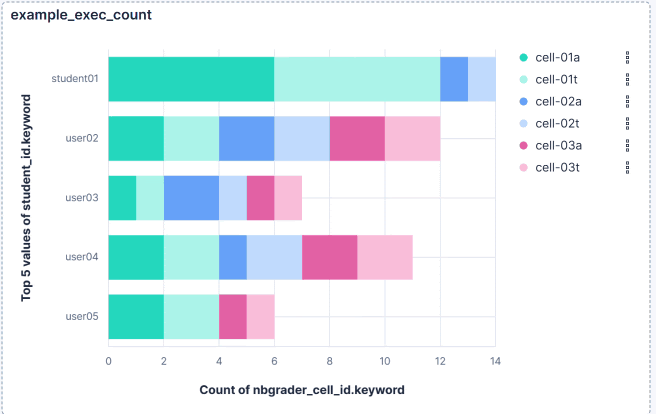

In [ ]:
import base64
import IPython

with open("images/mcj-es-sample-bar-real.gif", "rb") as f:
    b64 = base64.b64encode(f.read()).decode("ascii")

display(IPython.display.HTML(f'<img src="data:image/gif;base64,{b64}" />'))

- 設定

<img src="./images/mcj-es-sample-bar-conf.png" height="50%" width="50%">

以下のセルを実行すると、無限ループを開始し、10秒ごとに実行ログをElasticSearchへ送信します。  

In [ ]:
from datetime import datetime, timezone, timedelta
import time
import os

JST = timezone(timedelta(hours=+9), 'JST')

# 自動更新する間隔（秒）
db_reload_span = 10

# 最初にすべてのログを読み込む
dt_from = datetime(1970, 1, 1, 0, 0, 0, tzinfo=JST)
dt_to = datetime.now(JST)
r = log2db(os.environ['JUPYTERHUB_API_TOKEN'], COURSE, ASSIGNMENT, dt_from=dt_from, dt_to=dt_to)
send_db_to_es(ES_HOST, ES_INDEX, get_db_rows(SQLITE_DB_PATH, SQLITE_QUERY), renew=True)


while True:
    latest_log_dt = datetime.now(timezone.utc) - timedelta(seconds=db_reload_span)
    r = log2db(os.environ['JUPYTERHUB_API_TOKEN'], COURSE, ASSIGNMENT, latest_log_dt)
    if r.status_code != 200:
        print(f'failed to collect logs')
        print(r.json())
        break
    send_db_to_es(ES_HOST, ES_INDEX, get_db_rows(SQLITE_DB_PATH, SQLITE_QUERY))
    time.sleep(db_reload_span)
